In [43]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

In [20]:
sys.path.append('..')

In [36]:
from vital.metrics import get_survival_metrics, get_risk_metrics, get_censoring_dist, include_exam_and_determine_label

In [25]:
# Import json file
with open("/tank-1/data/NLST/json/train_our_updated.json") as f:
    train_data = json.load(f)

with open("/tank-1/data/checkpoints/lung_survival/predictions_fanciful-morning-198.json") as f:
    data = json.load(f)


In [26]:
censoring_dist = get_censoring_dist(train_data)

In [27]:
censoring_dist

{'0': 0.9860950173812297,
 '1': 0.9764641732812178,
 '2': 0.9682088843711711,
 '3': 0.9618680525189961,
 '4': 0.9563014097865051,
 '5': 0.9507666066496202}

In [4]:
df = pd.DataFrame(data)
df.head()

,cancer_risk,gold,censors,pid,study,series,screen_timepoint,institution,cancer_laterality,y,time_at_event,y_seq,y_mask
0,"[0.0684129148721695, 0.0684129148721695, 0.068...",0,5,100005,1.2.840.113654.2.55.15354675073554904449223965...,1.2.840.113654.2.55.33065633377443331729120546...,0,A,"[4, False]",0,5,"[0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1]"
1,"[0.055310655385255814, 0.055310655385255814, 0...",0,5,100005,1.2.840.113654.2.55.10251457513072085864761297...,1.2.840.113654.2.55.17324290215190661437113320...,1,A,"[4, False]",0,5,"[0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1]"
2,"[0.0650087296962738, 0.0650087296962738, 0.065...",0,4,100005,1.2.840.113654.2.55.10940192540799808329280702...,1.2.840.113654.2.55.21247452796009259375851140...,2,A,"[4, False]",0,4,"[0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 0]"
3,"[0.7439128756523132, 0.7439128756523132, 0.743...",1,1,100012,1.2.840.113654.2.55.23803494144550801138646327...,1.2.840.113654.2.55.24023112856488152536348979...,0,A,"[4, False]",1,1,"[0, 1, 1, 1, 1, 1]","[1, 1, 0, 0, 0, 0]"
4,"[0.834811270236969, 0.834811270236969, 0.83481...",1,0,100012,1.2.840.113654.2.55.38321092839390108338558865...,1.2.840.113654.2.55.50761756412482430061802871...,1,A,"[4, False]",1,0,"[1, 1, 1, 1, 1, 1]","[1, 0, 0, 0, 0, 0]"


In [16]:
probs = np.stack(df['cancer_risk'])
golds = np.stack(df['gold'])
censors = np.stack(df['censors'])
y = np.stack(df['y'])

In [28]:
get_survival_metrics(censors, probs, golds, censoring_dist, max_followup=6, mode="test")

{'test/1_year_auc': 0.9051095688288978,
 'test/1_year_apscore': 0.34536592568642366,
 'test/1_year_prauc': 0.3419757094351837,
 'test/2_year_auc': 0.8709804075316443,
 'test/2_year_apscore': 0.28962239869804773,
 'test/2_year_prauc': 0.28721173454713994,
 'test/3_year_auc': 0.8262443883877035,
 'test/3_year_apscore': 0.2590022912337312,
 'test/3_year_prauc': 0.2571002202346898,
 'test/4_year_auc': 0.8036171141186754,
 'test/4_year_apscore': 0.24794038551741635,
 'test/4_year_prauc': 0.24633575998586463,
 'test/5_year_auc': 0.7928525249883775,
 'test/5_year_apscore': 0.26507490804505307,
 'test/5_year_prauc': 0.2639440942129279,
 'test/6_year_auc': 0.7943414252333758,
 'test/6_year_apscore': 0.32475356955194146,
 'test/6_year_prauc': 0.3237484360053509,
 'test/c_index': 0.7878771668402706}

In [29]:
get_risk_metrics(censors, probs, golds, max_followup=6, mode="test")

/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


{'test/1_year_risk_auc': nan,
 'test/1_year_risk_apscore': 0.0,
 'test/1_year_risk_prauc': 0.5,
 'test/2_year_risk_auc': 0.8112370079031404,
 'test/2_year_risk_apscore': 0.03468701038026302,
 'test/2_year_risk_prauc': 0.03216139175284814,
 'test/3_year_risk_auc': 0.7573209877516898,
 'test/3_year_risk_apscore': 0.05107753851243775,
 'test/3_year_risk_prauc': 0.0491930939732757,
 'test/4_year_risk_auc': 0.7428372889189211,
 'test/4_year_risk_apscore': 0.06670554693203688,
 'test/4_year_risk_prauc': 0.06512683166825244,
 'test/5_year_risk_auc': 0.7416040439365238,
 'test/5_year_risk_apscore': 0.09344535020918082,
 'test/5_year_risk_prauc': 0.09184495213985627,
 'test/6_year_risk_auc': 0.7489758660610917,
 'test/6_year_risk_apscore': 0.14220418340755847,
 'test/6_year_risk_prauc': 0.14010676767145896}

# TPR at x FPR and Precision at x Recall

In [37]:
def get_probs_and_golds(probs, censor_times, golds, followup, fup_lower_bound=-1):
    probs_for_eval = []
    golds_for_eval = []
    for prob_arr, censor_time, gold in zip(probs, censor_times, golds):
        include, label = include_exam_and_determine_label(censor_time, gold, followup, fup_lower_bound)
        if include:
            probs_for_eval.append(prob_arr[followup])
            golds_for_eval.append(label)
    return probs_for_eval, golds_for_eval



# FUP lower bound
## Survival
default value = -1

## Risk
value = 0

In [84]:
def get_tpr_at_fpr(probs, censors, golds, fpr_target=0.1, fup_lower_bound=-1):
    tpr_list = []
    for i in range(6):
        p, g = get_probs_and_golds(probs, censors, golds, i, fup_lower_bound)
        # Get TPR at x FPR
        fpr, tpr, _ = roc_curve(np.array(g), np.array(p))
        tpr_val = tpr[np.where(fpr <= fpr_target)[0][-1]]
        tpr_list.append(tpr_val)
    return tpr_list

def get_precision_at_recall(probs, censors, golds, recall_target=0.8):
    precision_list = []
    for i in range(6):
        p, g = get_probs_and_golds(probs, censors, golds, i,    fup_lower_bound=-1)
        # Get precision at x recall
        precision, recall, _ = precision_recall_curve(np.array(g), np.array(p))
        precision_val = precision[np.where(recall >= recall_target)[0][-1]]
        precision_list.append(precision_val)
    return precision_list
    

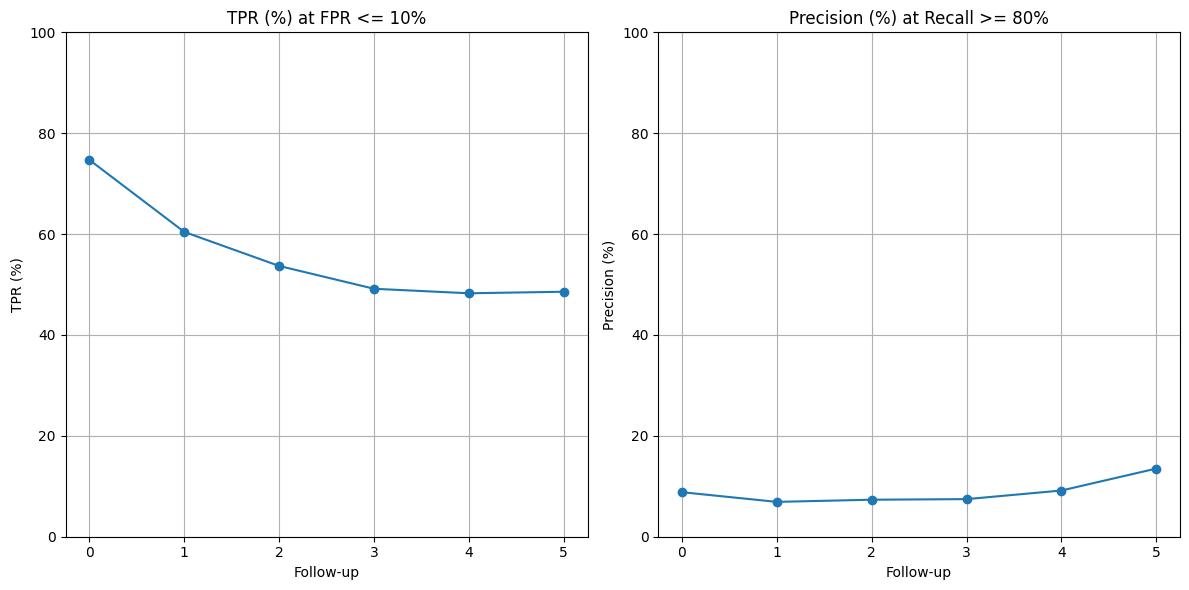

TPR (%) values at FPR <= 10.0%: [74.71264367816092, 60.431654676258994, 53.68421052631579, 49.159663865546214, 48.26388888888889, 48.57142857142857]
Precision (%) values at Recall >= 80.0%: [8.827238335435057, 6.909315237507712, 7.335907335907336, 7.453416149068323, 9.1593973037272, 13.512064343163537]


In [91]:
# Plot tprs at fpr and precisions at recall grapphs. Two different graphs. for followup 0 to 5. Add grids to the plots.

import matplotlib.pyplot as plt

fpr_target = 0.1
recall_target = 0.8

tpr_values = get_tpr_at_fpr(probs, censors, golds, fpr_target)
precision_values = get_precision_at_recall(probs, censors, golds, recall_target)

# Convert decimals to percentages
tpr_percent = [v * 100 if v is not None else None for v in tpr_values]
precision_percent = [v * 100 if v is not None else None for v in precision_values]

# Plot TPR at FPR
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(6), tpr_percent, marker='o')
plt.title(f'TPR (%) at FPR <= {fpr_target*100:.0f}%')
plt.xlabel('Follow-up')
plt.ylabel('TPR (%)')
plt.xticks(range(6))
plt.ylim(0, 100)
plt.grid()  # Add grid to first plot

# Plot Precision at Recall
plt.subplot(1, 2, 2)
plt.plot(range(6), precision_percent, marker='o')
plt.title(f'Precision (%) at Recall >= {recall_target*100:.0f}%')
plt.xlabel('Follow-up')
plt.ylabel('Precision (%)')
plt.xticks(range(6))
plt.ylim(0, 100)
plt.grid()  # Add grid to second plot

plt.tight_layout()
plt.show()

print("TPR (%) values at FPR <= {}%: {}".format(fpr_target*100, tpr_percent))
print("Precision (%) values at Recall >= {}%: {}".format(recall_target*100, precision_percent))